In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")

In [3]:
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [4]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [5]:
nav['date'] = pd.to_datetime(nav['date'])

In [6]:
nav = nav.sort_values(['amfi_code', 'date'])

In [7]:
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

In [8]:
nav.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [9]:
nav = nav.dropna(subset=['daily_return'])

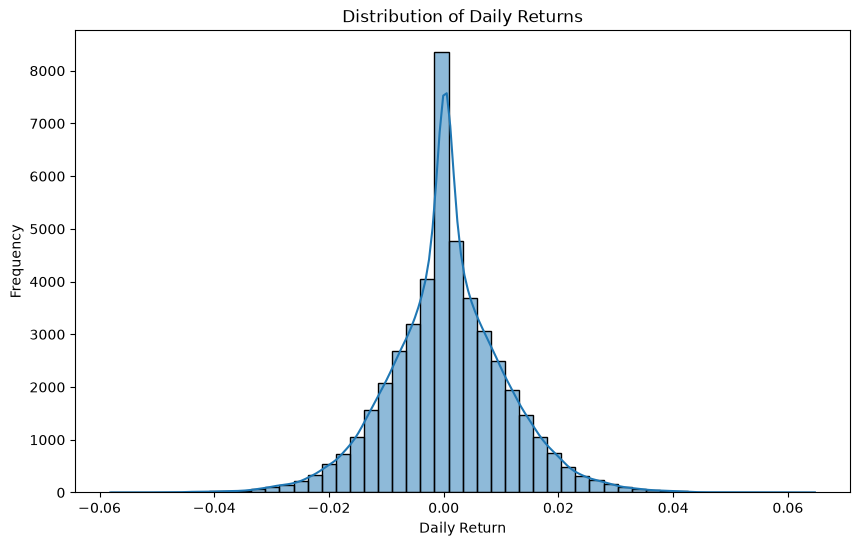

In [10]:
plt.figure(figsize=(10,6))

sns.histplot(nav['daily_return'], bins=50, kde=True)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [11]:
plt.savefig(
    "../reports/daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [12]:
plt.savefig(
    "../reports/daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [13]:
nav['date'].min(), nav['date'].max()

(Timestamp('2022-01-04 00:00:00'), Timestamp('2026-05-29 00:00:00'))

In [14]:
cagr_data = nav.copy()

In [15]:
latest_date = cagr_data['date'].max()

latest_date

Timestamp('2026-05-29 00:00:00')

In [16]:
def calculate_cagr(start_nav, end_nav, years):
    return ((end_nav / start_nav) ** (1 / years)) - 1

In [17]:
cagr_results = []

In [18]:
for fund in cagr_data['amfi_code'].unique():

    fund_data = cagr_data[cagr_data['amfi_code'] == fund].sort_values('date')

    latest_nav = fund_data.iloc[-1]['nav']
    latest_date = fund_data.iloc[-1]['date']

    result = {'amfi_code': fund}

    for years in [1, 3, 5]:

        start_date = latest_date - pd.DateOffset(years=years)

        past_data = fund_data[fund_data['date'] >= start_date]

        if len(past_data) > 0:

            start_nav = past_data.iloc[0]['nav']

            result[f'CAGR_{years}Y'] = calculate_cagr(
                start_nav,
                latest_nav,
                years
            )

        else:

            result[f'CAGR_{years}Y'] = np.nan

    cagr_results.append(result)

In [19]:
cagr_df = pd.DataFrame(cagr_results)

In [20]:
cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-0.022243,0.012926,0.025290
1,100025,0.037050,0.039164,0.039866
2,100033,0.532324,0.324425,0.264128
3,101206,0.479241,0.289677,0.204150
4,101207,-0.239860,-0.041524,0.071873


In [21]:
cagr_display = cagr_df.copy()

cagr_display['CAGR_1Y'] = (cagr_display['CAGR_1Y'] * 100).round(2)
cagr_display['CAGR_3Y'] = (cagr_display['CAGR_3Y'] * 100).round(2)
cagr_display['CAGR_5Y'] = (cagr_display['CAGR_5Y'] * 100).round(2)

cagr_display.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-2.22,1.29,2.53
1,100025,3.70,3.92,3.99
2,100033,53.23,32.44,26.41
3,101206,47.92,28.97,20.41
4,101207,-23.99,-4.15,7.19


In [22]:
cagr_display.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

In [23]:
risk_free_rate = 0.065
daily_rf = risk_free_rate / 252

In [24]:
sharpe_results = []

In [25]:
for fund in nav['amfi_code'].unique():

    fund_data = nav[nav['amfi_code'] == fund]

    avg_return = fund_data['daily_return'].mean()

    std_return = fund_data['daily_return'].std()

    sharpe_ratio = ((avg_return - daily_rf) / std_return) * np.sqrt(252)

    sharpe_results.append({
        'amfi_code': fund,
        'Sharpe_Ratio': sharpe_ratio
    })

In [26]:
sharpe_df = pd.DataFrame(sharpe_results)

In [27]:
sharpe_df = sharpe_df.sort_values(
    by='Sharpe_Ratio',
    ascending=False
)

In [28]:
sharpe_df.head(10)

,amfi_code,Sharpe_Ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


In [29]:
sortino_results = []

In [30]:
for fund in nav['amfi_code'].unique():

    fund_data = nav[nav['amfi_code'] == fund]

    avg_return = fund_data['daily_return'].mean()

    downside_returns = fund_data[fund_data['daily_return'] < 0]['daily_return']

    downside_std = downside_returns.std()

    sortino_ratio = ((avg_return - daily_rf) / downside_std) * np.sqrt(252)

    sortino_results.append({
        'amfi_code': fund,
        'Sortino_Ratio': sortino_ratio
    })

In [31]:
sortino_df = pd.DataFrame(sortino_results)

In [32]:
sortino_df = sortino_df.sort_values(
    by='Sortino_Ratio',
    ascending=False
)

In [33]:
sortino_df.head(10)

,amfi_code,Sortino_Ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


In [34]:
sortino_df.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

In [35]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [36]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [37]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [38]:
benchmark['index_name'].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [39]:
benchmark['date'] = pd.to_datetime(benchmark['date'])

In [40]:
nifty100 = benchmark[benchmark['index_name'] == 'NIFTY100'].copy()

In [41]:
nifty100 = nifty100.sort_values('date')

In [42]:
nifty100['benchmark_return'] = nifty100['close_value'].pct_change()

In [43]:
nifty100 = nifty100.dropna()


In [44]:
from scipy.stats import linregress

In [45]:
alpha_beta_results = []

In [46]:
for fund in nav['amfi_code'].unique():

    fund_data = nav[nav['amfi_code'] == fund][['date', 'daily_return']]

    merged = pd.merge(
        fund_data,
        nifty100[['date', 'benchmark_return']],
        on='date',
        how='inner'
    )

    if len(merged) > 10:

        slope, intercept, r_value, p_value, std_err = linregress(
            merged['benchmark_return'],
            merged['daily_return']
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta_results.append({
            'amfi_code': fund,
            'Alpha': alpha,
            'Beta': beta
        })

In [47]:
alpha_beta_df = pd.DataFrame(alpha_beta_results)

In [48]:
alpha_beta_df.head()

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [49]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [50]:
alpha_beta_df.head()

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [51]:
drawdown_results = []

In [57]:
drawdown_results = []

for fund in nav['amfi_code'].unique():

    fund_data = nav[nav['amfi_code'] == fund].copy()
    fund_data = fund_data.sort_values('date')

    fund_data['running_max'] = fund_data['nav'].cummax()
    fund_data['drawdown'] = (
        fund_data['nav'] /
        fund_data['running_max']
    ) - 1

    worst_index = fund_data['drawdown'].idxmin()

    worst_date = fund_data.loc[worst_index, 'date']

    peak_date = fund_data.loc[
        fund_data.loc[:worst_index, 'nav'].idxmax(),
        'date'
    ]

    drawdown_results.append({
        'amfi_code': fund,
        'Maximum_Drawdown': fund_data['drawdown'].min(),
        'Peak_Date': peak_date,
        'Worst_Date': worst_date
    })

In [58]:
drawdown_df = pd.DataFrame(drawdown_results)

In [59]:
drawdown_df = drawdown_df.sort_values(
    by='Maximum_Drawdown'
)

In [60]:
drawdown_df.head()


,amfi_code,Maximum_Drawdown,Peak_Date,Worst_Date
22,119599,-0.525742,2023-01-17,2025-10-28
17,119095,-0.516778,2025-05-22,2026-05-11
4,101207,-0.354469,2024-11-21,2026-05-11
39,149324,-0.311719,2024-05-03,2025-01-03
21,119598,-0.287060,2024-08-28,2025-05-14


In [61]:
drawdown_df.to_csv(
    "../reports/maximum_drawdown.csv",
    index=False
)

In [62]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')

In [63]:
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')

In [64]:
scorecard = cagr_df[['amfi_code', 'CAGR_3Y']].merge(
    sharpe_df[['amfi_code', 'Sharpe_Ratio']],
    on='amfi_code'
)

scorecard = scorecard.merge(
    alpha_beta_df[['amfi_code', 'Alpha']],
    on='amfi_code'
)

scorecard = scorecard.merge(
    drawdown_df[['amfi_code', 'Maximum_Drawdown']],
    on='amfi_code'
)

scorecard = scorecard.merge(
    fund_master[['amfi_code', 'expense_ratio_pct']],
    on='amfi_code'
)

In [65]:
scorecard.head()

,amfi_code,CAGR_3Y,Sharpe_Ratio,Alpha,Maximum_Drawdown,expense_ratio_pct
0,100016,0.012926,-0.201517,0.037476,-0.247344,1.55
1,100025,0.039164,-0.567095,0.042818,-0.043083,0.56
2,100033,0.324425,1.093699,0.271954,-0.162172,1.38
3,101206,0.289677,1.027213,0.213998,-0.112916,1.60
4,101207,-0.041524,0.162661,0.108971,-0.354469,1.53


In [66]:
scorecard['Return_Rank'] = scorecard['CAGR_3Y'].rank(ascending=False)

scorecard['Sharpe_Rank'] = scorecard['Sharpe_Ratio'].rank(ascending=False)

scorecard['Alpha_Rank'] = scorecard['Alpha'].rank(ascending=False)

scorecard['Expense_Rank'] = scorecard['expense_ratio_pct'].rank(ascending=True)

scorecard['Drawdown_Rank'] = scorecard['Maximum_Drawdown'].rank(ascending=False)

In [67]:
scorecard['Fund_Score'] = (
    (41 - scorecard['Return_Rank']) * 0.30 +
    (41 - scorecard['Sharpe_Rank']) * 0.25 +
    (41 - scorecard['Alpha_Rank']) * 0.20 +
    (41 - scorecard['Expense_Rank']) * 0.15 +
    (41 - scorecard['Drawdown_Rank']) * 0.10
)

In [68]:
scorecard = scorecard.sort_values(
    by='Fund_Score',
    ascending=False
)

In [69]:
scorecard[['amfi_code', 'Fund_Score']].head(10)

,amfi_code,Fund_Score
34,148567,34.500
25,120505,32.900
30,120843,32.800
2,100033,32.300
24,120504,32.000
16,119094,30.800
19,119551,29.925
36,148569,29.475
3,101206,27.275
21,119598,26.950


In [70]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

In [71]:
top5_funds = scorecard.head(5)['amfi_code'].tolist()

top5_funds

[148567, 120505, 120843, 100033, 120504]

In [72]:
top5_nav = nav[nav['amfi_code'].isin(top5_funds)].copy()

In [73]:
latest_date = top5_nav['date'].max()

start_date = latest_date - pd.DateOffset(years=3)

top5_nav = top5_nav[top5_nav['date'] >= start_date]

In [74]:
benchmark['date'] = pd.to_datetime(benchmark['date'])

benchmark_3yr = benchmark[
    (benchmark['date'] >= start_date) &
    (benchmark['index_name'].isin(['NIFTY50', 'NIFTY100']))
]

In [75]:
import plotly.express as px

In [76]:
fig = px.line(
    top5_nav,
    x='date',
    y='nav',
    color='amfi_code',
    title='Top 5 Funds - Last 3 Years'
)

fig.show()

In [77]:
import plotly.graph_objects as go

for index_name in ['NIFTY50', 'NIFTY100']:

    data = benchmark_3yr[
        benchmark_3yr['index_name'] == index_name
    ]

    fig.add_trace(
        go.Scatter(
            x=data['date'],
            y=data['close_value'],
            mode='lines',
            name=index_name
        )
    )

fig.show()

In [78]:
fig.write_html("../reports/benchmark_comparison.html")

In [79]:
tracking_error_results = []

for fund in top5_funds:

    fund_data = nav[
        nav['amfi_code'] == fund
    ][['date', 'daily_return']]

    benchmark_returns = nifty100[
        ['date', 'benchmark_return']
    ]

    merged = pd.merge(
        fund_data,
        benchmark_returns,
        on='date'
    )

    tracking_error = (
        (merged['daily_return'] -
         merged['benchmark_return']).std()
    ) * np.sqrt(252)

    tracking_error_results.append({
        'amfi_code': fund,
        'Tracking_Error': tracking_error
    })

In [80]:
tracking_error_df = pd.DataFrame(
    tracking_error_results
)

tracking_error_df

,amfi_code,Tracking_Error
0,148567,0.189664
1,120505,0.231968
2,120843,0.206425
3,100033,0.228699
4,120504,0.191587


In [81]:
tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)